In [7]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [8]:

sales = pd.read_csv('data/sales.csv')
items = pd.read_csv('data/items.csv')

# 1. Data Type Conversion
sales['date'] = pd.to_datetime(sales['date'])

# 2. Merge Tables
# It is critical to do a left join on sales to keep every transaction
df = sales.merge(items, on='item_name', how='left')

df.head()

,date,time,item_name,transaction_type,own_cup,surcharge,customer_id,price,production_cost,item_type,drink_temperature,drink_type
0,2022-01-01,07:03:30,Cold Brew,Takeout,True,False,26946,4.75,1.35,Drink,Cold,Coffee
1,2022-01-01,07:30:58,Iced Coffee,Takeout,True,False,24356,4.00,1.10,Drink,Cold,Coffee
2,2022-01-01,08:32:23,Iced Latte,Takeout,False,False,3760,4.60,1.25,Drink,Cold,Coffee
3,2022-01-01,08:45:03,Latte,Dine-in,True,False,5900,4.50,1.20,Drink,Hot,Coffee
4,2022-01-01,09:03:47,Latte,Takeout,False,False,11589,4.50,1.20,Drink,Hot,Coffee


In [9]:
# Construction: Sept 4, 2022 - Dec 12, 2022 
# Rebrand/Surcharge Start: Nov 1, 2023 

conditions = [
    (df['date'] >= '2022-09-04') & (df['date'] <= '2022-12-12'),
    (df['date'] < '2023-11-01'),
    (df['date'] >= '2023-11-01')
]
choices = ['Construction', 'Pre-Rebrand', 'Post-Rebrand']

# Note: Any dates before Construction will be labeled 'Pre-Rebrand' by this logic,
# which is fine, but be aware of seasonality if you have data from early 2022.
df['period'] = np.select(conditions, choices, default='Other')

SURCHARGE_AMT = 0.50

df['surcharge_amt'] = np.where(df['surcharge'] == True, SURCHARGE_AMT, 0.0)
df['total_revenue'] = df['price'] + df['surcharge_amt']

# Case assumption: Production costs are constant [cite: 126]
df['profit'] = df['total_revenue'] - df['production_cost']
df.head()

,date,time,item_name,transaction_type,own_cup,surcharge,customer_id,price,production_cost,item_type,drink_temperature,drink_type,period,surcharge_amt,total_revenue,profit
0,2022-01-01,07:03:30,Cold Brew,Takeout,True,False,26946,4.75,1.35,Drink,Cold,Coffee,Pre-Rebrand,0.0,4.75,3.40
1,2022-01-01,07:30:58,Iced Coffee,Takeout,True,False,24356,4.00,1.10,Drink,Cold,Coffee,Pre-Rebrand,0.0,4.00,2.90
2,2022-01-01,08:32:23,Iced Latte,Takeout,False,False,3760,4.60,1.25,Drink,Cold,Coffee,Pre-Rebrand,0.0,4.60,3.35
3,2022-01-01,08:45:03,Latte,Dine-in,True,False,5900,4.50,1.20,Drink,Hot,Coffee,Pre-Rebrand,0.0,4.50,3.30
4,2022-01-01,09:03:47,Latte,Takeout,False,False,11589,4.50,1.20,Drink,Hot,Coffee,Pre-Rebrand,0.0,4.50,3.30


In [10]:
def calculate_kpis(data):
    # Filter for drinks only for cup metrics, as per case logic
    # own_cup is N/A for merch, so we can technically just use mean(),
    # but being explicit is safer.
    drinks_only = data[data['item_type'] == 'Drink']
    
    return pd.Series({
        # --- Financials ---
        'Total Revenue': data['total_revenue'].sum(),
        'Total Profit': data['profit'].sum(),
        'Profit Margin': (data['profit'].sum() / data['total_revenue'].sum()) * 100,
        'Avg Order Value': data['total_revenue'].mean(),
        
        # --- Volume ---
        'Total Transactions': len(data),
        'Daily Txn Avg': len(data) / data['date'].nunique(),
        
        # --- Behaviour (Sustainability) ---
        # Percentage of drinks where own_cup is True
        'Reusable Cup Rate (%)': drinks_only['own_cup'].mean() * 100,
        
        # Percentage of orders that are Dine-In
        'Dine-In Rate (%)': (data['transaction_type'] == 'Dine-in').mean() * 100,
        
        # --- Surcharge Impact ---
        'Total Surcharges Collected': data['surcharge_amt'].sum(),
        'Surcharged Txn Count': data['surcharge'].sum()
    })

# Group by Period and Apply
kpi_table = df.groupby('period').apply(calculate_kpis).transpose()

# Reorder columns to match chronological flow
cols = ['Construction', 'Pre-Rebrand', 'Post-Rebrand']
# Filter to ensure columns exist (in case your csv doesn't have construction dates)
existing_cols = [c for c in cols if c in kpi_table.columns]
kpi_table = kpi_table[existing_cols]

print(kpi_table)

period                      Construction   Pre-Rebrand  Post-Rebrand
Total Revenue               10086.600000  81390.600000  74890.900000
Total Profit                 7154.950000  57697.450000  52632.200000
Profit Margin                  70.935201     70.889574     70.278498
Avg Order Value                 4.849327      4.860882      5.434359
Total Transactions           2080.000000  16744.000000  13781.000000
Daily Txn Avg                  20.800000     29.427065     32.274005
Reusable Cup Rate (%)          38.756948     40.127868     48.674968
Dine-In Rate (%)               30.288462     30.584090     40.925912
Total Surcharges Collected      0.000000      0.000000   1726.000000
Surcharged Txn Count            0.000000      0.000000   3452.000000


/var/folders/tw/9jbdr70n63z4pj9wq1636zjm0000gn/T/ipykernel_30718/1476901499.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kpi_table = df.groupby('period').apply(calculate_kpis).transpose()


/var/folders/tw/9jbdr70n63z4pj9wq1636zjm0000gn/T/ipykernel_30718/3783450809.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_financials = df.groupby('period').apply(


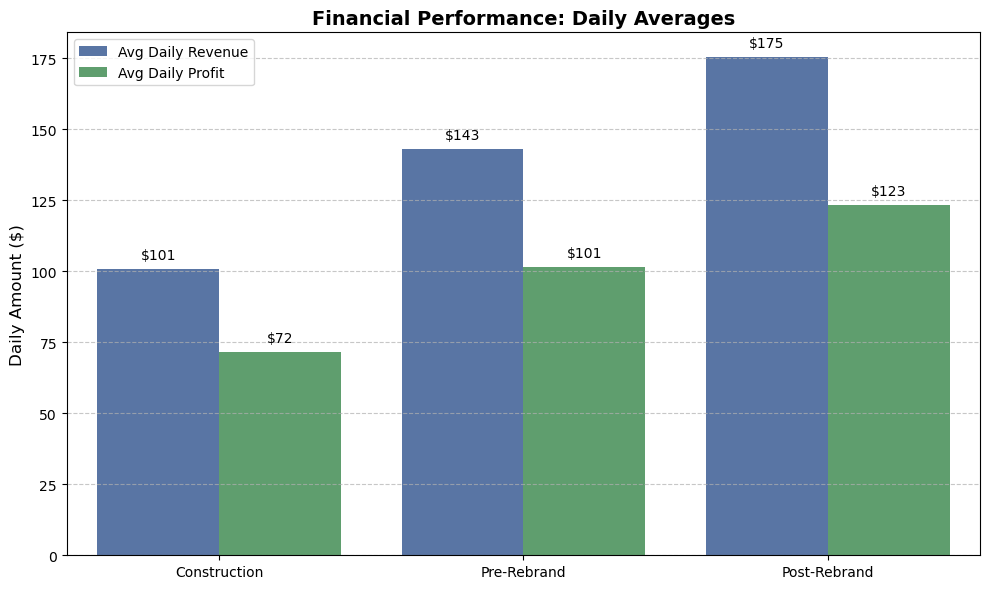

In [11]:

# 1. Prepare the Data for Plotting
# We need to reshape the data so Seaborn can read it easily.
# We are calculating DAILY averages to normalize for different time period lengths.

# Re-using the 'df' from the previous step to get raw daily stats
daily_financials = df.groupby('period').apply(
    lambda x: pd.Series({
        'Avg Daily Revenue': x['total_revenue'].sum() / x['date'].nunique(),
        'Avg Daily Profit': x['profit'].sum() / x['date'].nunique()
    })
).reset_index()

# Melt the dataframe to make it "long" for Seaborn (easy side-by-side plotting)
plot_data = daily_financials.melt(
    id_vars='period', 
    var_name='Metric', 
    value_name='Amount ($)'
)

# 2. Define Order of Periods (Chronological)
period_order = ['Construction', 'Pre-Rebrand', 'Post-Rebrand']

# 3. Create the Chart
plt.figure(figsize=(10, 6))

# Use a color palette that distinguishes Money In (Rev) vs Money Kept (Profit)
sns.barplot(
    data=plot_data, 
    x='period', 
    y='Amount ($)', 
    hue='Metric', 
    order=period_order,
    palette={'Avg Daily Revenue': '#4c72b0', 'Avg Daily Profit': '#55a868'}
)

# 4. Formatting for Impact
plt.title('Financial Performance: Daily Averages', fontsize=14, fontweight='bold')
plt.ylabel('Daily Amount ($)', fontsize=12)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title=None)

# Add value labels on top of bars for precision
for p in plt.gca().patches:
    if p.get_height() > 0: # Avoid labeling empty bars
        plt.gca().annotate(f'${p.get_height():.0f}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='bottom', 
                           xytext=(0, 5), 
                           textcoords='offset points')

plt.tight_layout()
plt.show()